In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sb
import warnings

warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("C:\\Desktop\\visa approval prediction\\us_visa approval prediction\\data\\raw\\EasyVisa.csv")

In [4]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [5]:
df.columns

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='str')

In [6]:
df.shape

(25480, 12)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  str    
 1   continent              25480 non-null  str    
 2   education_of_employee  25480 non-null  str    
 3   has_job_experience     25480 non-null  str    
 4   requires_job_training  25480 non-null  str    
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  str    
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  str    
 10  full_time_position     25480 non-null  str    
 11  case_status            25480 non-null  str    
dtypes: float64(1), int64(2), str(9)
memory usage: 3.4 MB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


In [9]:
numeric_features=df.select_dtypes(exclude=["object"]).columns
categorical_features=df.select_dtypes(include=["object"]).columns.difference(["case_id"])

print(type(numeric_features))
print(type(categorical_features))
print()

print(f" This dataset have {len(numeric_features)} numeric feature:{list(numeric_features)}")
print()
print(f"This dataset have {len(categorical_features)} categorical feature:{list(categorical_features)}")

<class 'pandas.Index'>
<class 'pandas.Index'>

 This dataset have 3 numeric feature:['no_of_employees', 'yr_of_estab', 'prevailing_wage']

This dataset have 8 categorical feature:['case_status', 'continent', 'education_of_employee', 'full_time_position', 'has_job_experience', 'region_of_employment', 'requires_job_training', 'unit_of_wage']


In [10]:
# Proportion of count data on categorical  features

for column in categorical_features:
    print(df[column].value_counts(normalize=True)*100)
    print("-----------------------------------------")

case_status
Certified    66.789639
Denied       33.210361
Name: proportion, dtype: float64
-----------------------------------------
continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64
-----------------------------------------
education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64
-----------------------------------------
full_time_position
Y    89.375981
N    10.624019
Name: proportion, dtype: float64
-----------------------------------------
has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64
-----------------------------------------
region_of_employment
Northeast    28.237834
South        27.539246
West         25.847724
Midwest      16.903454
Island        1.471743
Name: proportion, dtype: float64
------

Univariate Analysis
- Purpose is to understand the distribution of values for a single varaible


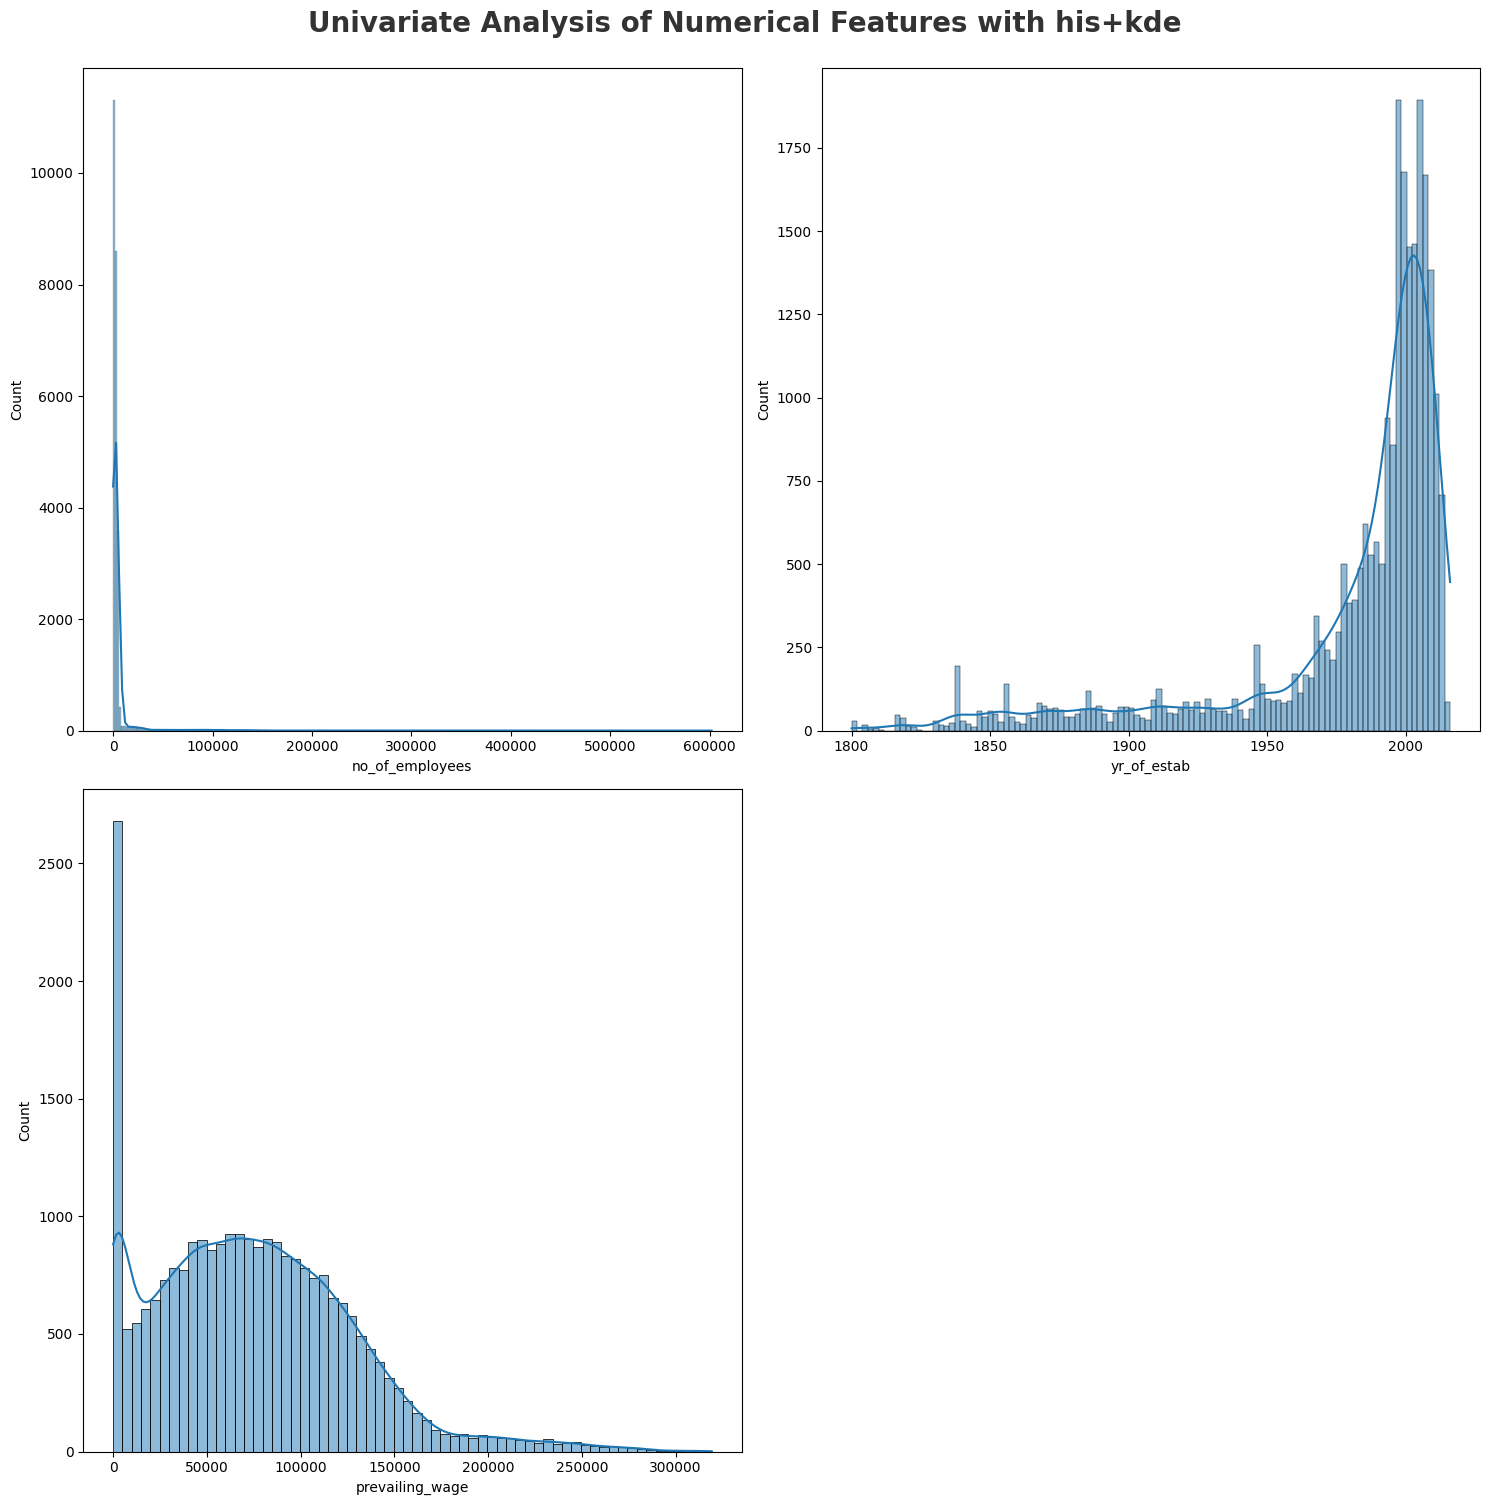

In [11]:
#  Univariate Analysis for Numeric features 

plt.figure(figsize=(15,15))
plt.suptitle("Univariate Analysis of Numerical Features with his+kde", fontsize=20,fontweight="bold",alpha=0.8,y=1)

for i, col in enumerate(numeric_features):
    plt.subplot(2,2,i+1) # i+1 ensure subplot indexing starts at 1
    sb.histplot(x=df[col],kde=True)   # Use histrogram together with KDE (Kernel Density Estimation)
    plt.xlabel(col)
plt.tight_layout()

Interpretation 

1. no-of_employee is extreme positive skewed(right-skewed) as it has a long tail extend to the right indicate extreme large outlier.

2. yr_of_estab is slight negative skewed (left-skewed), as tail extend toward older years indicate most companies are recently established.

3. prevailing_wage is positive skewed (right-skewed) as long tail extend toward right indicate outlier at high wages values in which most worker earn moderate wages and few high income stretch the distribution.

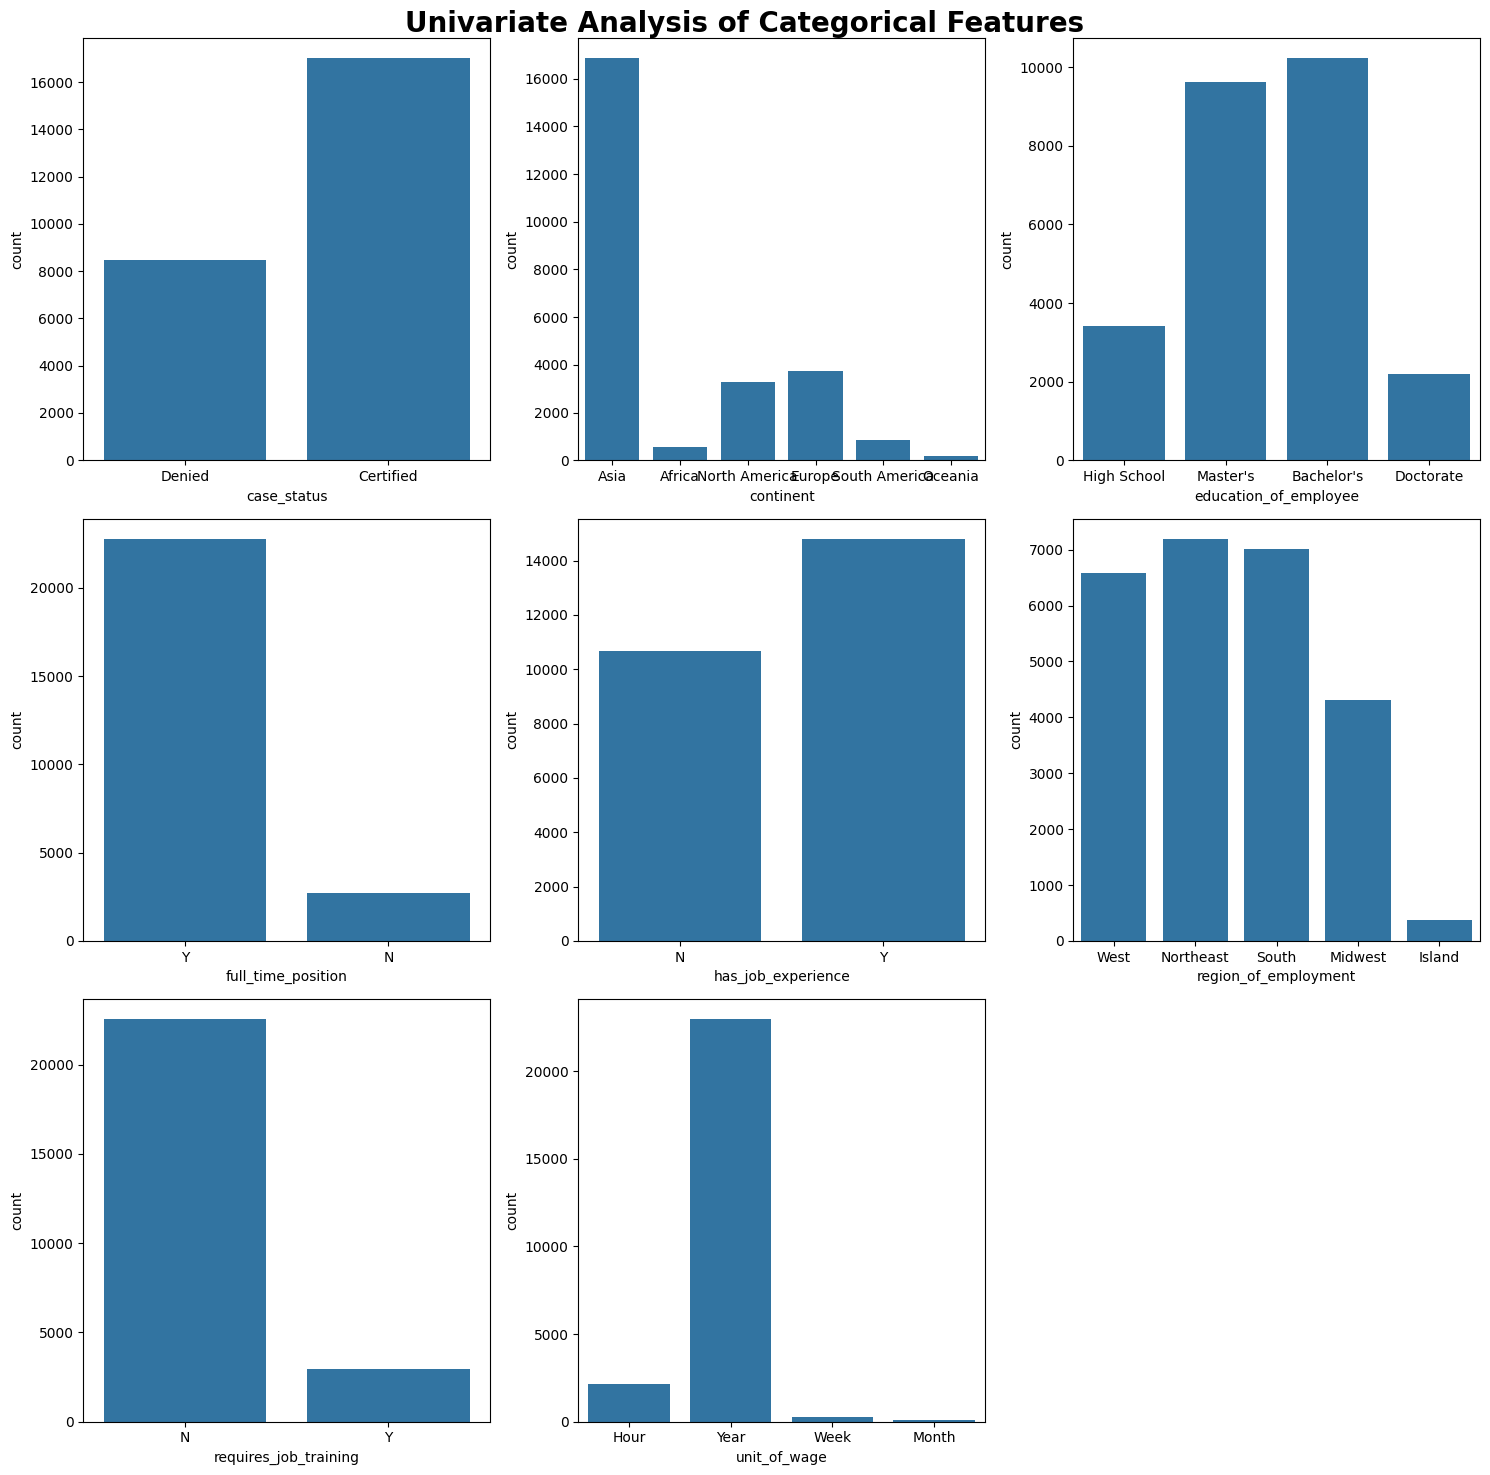

In [12]:
# Categorical feature univariety analysis

plt.figure(figsize=(15,15))
plt.suptitle("Univariate Analysis of Categorical Features", fontsize=20, fontweight="bold" )

for i, column in enumerate(categorical_features):
    plt.subplot(3,3,i+1)
    sb.countplot(x=df[column])
    plt.xlabel(column)

plt.tight_layout()

Interpretation

1. The distribution of requires_job_training, unit_of_wage, continent, full_time_position have single dominant category

2. The rest columns are balanced

 Multivariate Analysis 

 Purpose is to analysis of more than one variable

In [ ]:
# Using variance inflation factor identify the relationship btw numeric variable(multicollinearity of numeric varaible)
# VIF usuually need 2 argument which is fullmatrix of all features and the index of the column
# We handle multicollinearity by using feature selecting method (PCA, varaince threshold)

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Select numeric features properly
x = df[numeric_features].values.astype(float)  
vif_results = []

# Step 3: Loop through each feature
for i, col in enumerate(numeric_features):
    vif_value = variance_inflation_factor(x,i) # insert 2 argument (full matrix, index of the column)
    
    # Step 4: Interpretation
    if vif_value == 1:
        interpretation = "No multicollinearity"
    elif vif_value < 5:
        interpretation = "Low multicollinearity"
    elif vif_value < 10:
        interpretation = "Moderate multicollinearity"
    else:
        interpretation = "High multicollinearity"
    
    # Step 5: Store results
    vif_results.append({
        "feature": col,
        "VIF":round(vif_value,2),
        "interpretation": interpretation
    })

# Step 6: Convert to DataFrame
vif_data = pd.DataFrame(vif_results).sort_values(by="VIF", ascending=False)

print(vif_data)

           feature   VIF         interpretation
1      yr_of_estab  3.05  Low multicollinearity
2  prevailing_wage  2.99  Low multicollinearity
0  no_of_employees  1.06  Low multicollinearity


Interpretation of VIF 

There is no multicollinearity between any numeric varaible

In [ ]:
# Use chi square test to identify the relationship of categorical variable (multicollinearity) 

from scipy.stats import chi2_contingency

chi2_result = []

for col in categorical_features:
    # Create frequency table
    contingency = pd.crosstab(df[col],df["case_status"])
    # Apply chi2 test 
    chi2,p,dof,expected = chi2_contingency(contingency)
    # Apply interpretation
    if p < 0.001:
        interpretation = "very strong relationship"
    elif p < 0.05:
        interpretation = "significant relationship"
    else:
        interpretation = "Not significant"
    chi2_result.append({
        "feature" : col,
        "chi2_stat" : chi2,
        "p_value" : p,
        "dof" : dof,
        "interpreation": interpretation
    })


chi_df = pd.DataFrame(chi2_result)
chi_df = chi_df.sort_values(by="p_value")
print(chi_df)

                 feature     chi2_stat        p_value  dof  \
0            case_status  25475.491853   0.000000e+00    1   
2  education_of_employee   2772.207275   0.000000e+00    3   
7           unit_of_wage   1108.507062  5.193385e-240    3   
4     has_job_experience    940.058096  1.922560e-206    1   
1              continent    351.380408   8.828798e-74    5   
5   region_of_employment    298.450836   2.338664e-63    4   
3     full_time_position      4.029932   4.469975e-02    1   
6  requires_job_training      1.752484   1.855647e-01    1   

              interpreation  
0  very strong relationship  
2  very strong relationship  
7  very strong relationship  
4  very strong relationship  
1  very strong relationship  
5  very strong relationship  
3  significant relationship  
6           Not significant  


Interpretation of chi square test 

1. Only requires_job_training is not correlated to the target variable

2. Others category features are multicollinearity

In [15]:
print(df.isnull().sum())

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64


In [16]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
25475    False
25476    False
25477    False
25478    False
25479    False
Length: 25480, dtype: bool

In [17]:
df.drop_duplicates() # drop duplicates record if any

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


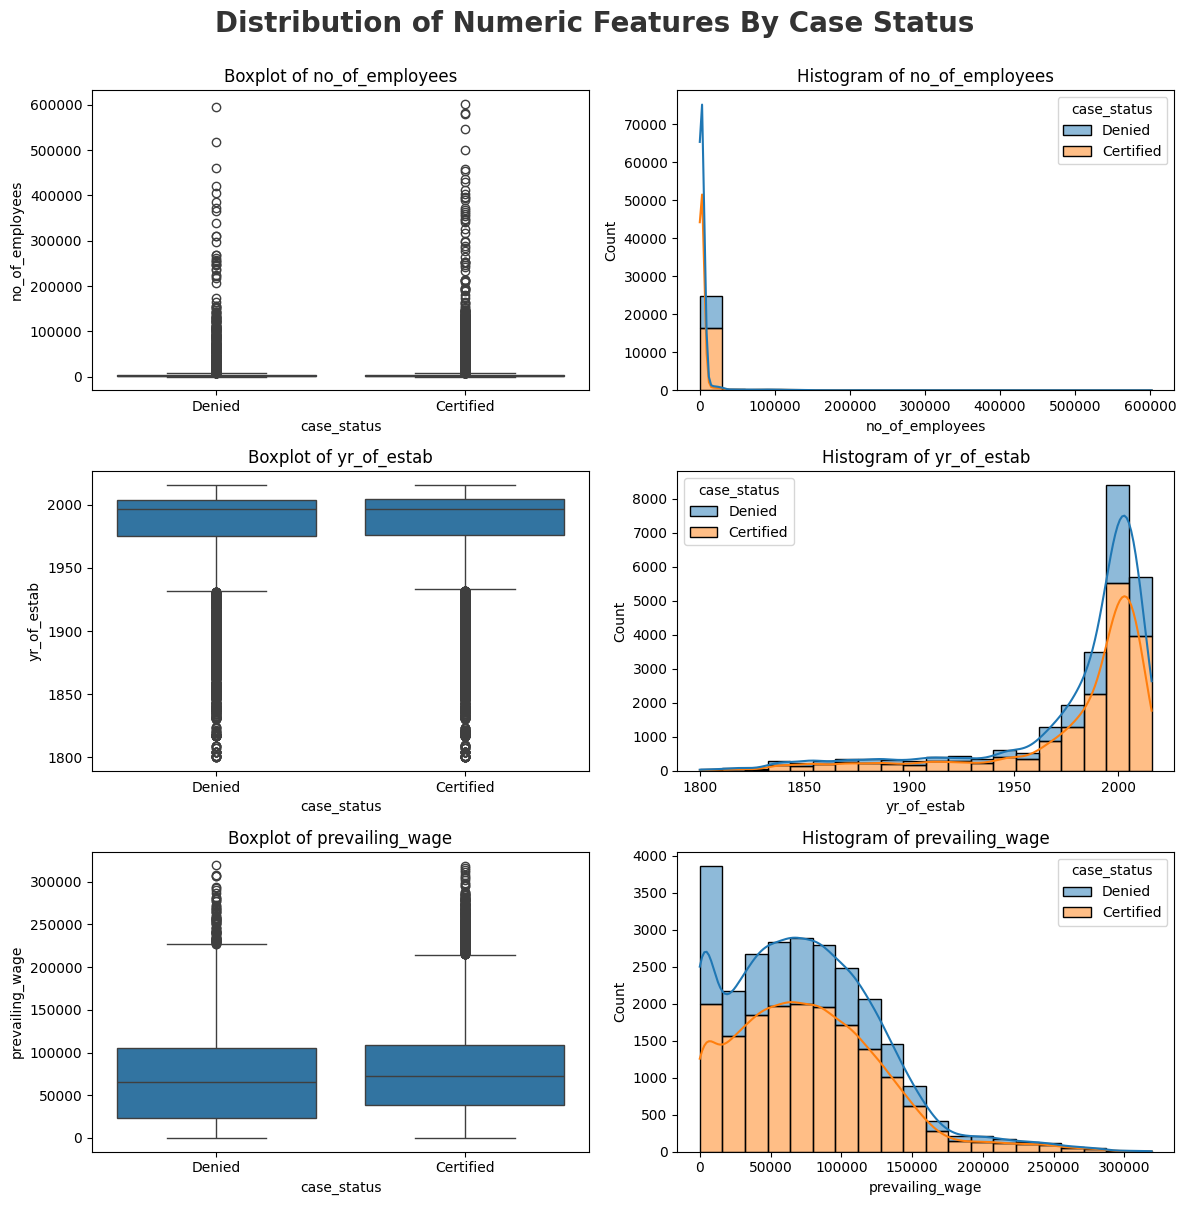

In [ ]:
# Multivariate Analysis 
# To check outlier of the numeric features and distribution of numeric features by case status 

fig, ax = plt.subplots(3,2, figsize=(12,12)) # create 3row 2column total 6 axes
fig.suptitle("Distribution of Numeric Features By Case Status",fontsize = 20,fontweight="bold",y=1, alpha=0.8)

for i,col in enumerate(numeric_features):
    # ax[i,o] place boxplot on the left cell of row i
    sb.boxplot(data=df,x=df["case_status"],y=col,ax=ax[i,0])
    ax[i,0].set_title(f"Boxplot of {col}",fontsize=12)
    # ax[i,1] place histogram on the right cell of row i
    sb.histplot(data=df,x=col,hue="case_status",bins=20,kde=True,multiple="stack",ax=ax[i,1]) # multiple =stack means stack the bar chart for denied and certified together 
    ax[i,1].set_title(f"Histogram of {col}",fontsize=12)
fig.tight_layout()

Interpretation 

no_of_employee
1. both certified and denied cases for boxplot have extreme outlier reach up to 600,000 employees, suggesting heaviliy right-skewed distribution.
2. Massive right skewed in histogram as majority of cases cluster in the first bin, a power transformation would suggest to use before modelling. 

yr_of_estab
1. Median establish around 2000 for both classes in boxplot, outliers are below lower bound (1800 - 1930)
2. Both distribution are left-skewed, notable spike in 2000-2010 for both classes in histogram.

prvailing_wage
1. Both group contain outlier reaching 300k, but  overall spread is wider for certified, lower whisker for denied reach closer to 0 meaning more low-wage denied cases.
2. Both distribution in histogram are right-skewed with long tail toward high wages, certified cases have more uniform spread across 30k-150k range 




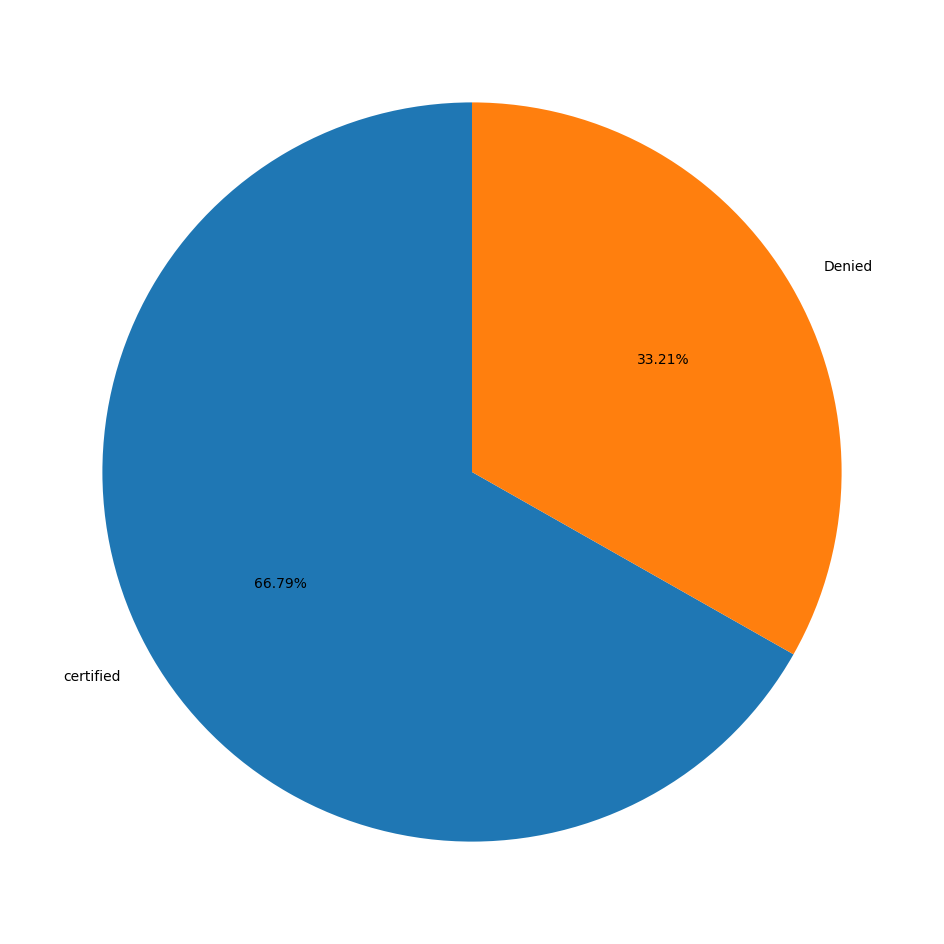

In [19]:
# Visualization of target variable - case_status

Normalize_percentage = df.case_status.value_counts(normalize=True)*100
label = ["certified","Denied"]

fig, ax = plt.subplots(figsize=(12,12))
ax.pie(Normalize_percentage,labels=label,startangle=90,autopct="%.2f%%")
plt.show()



Interpretation 

1. The targeted variable - case_status show slightly imbalance data in which certified cases has more count than the denied cases.
2. We could do stratified sampling for the dataset to ensure training and test set retain the same class proportion as the original dataset 

In [20]:
# Multivariate analysis
# Find out the impact of continent on case status

df.groupby("continent")["case_status"].value_counts(normalize=True).to_frame()*100

proportion
continent     case_status            
Africa        Certified     72.050817
              Denied        27.949183
Asia          Certified     65.310480
              Denied        34.689520
Europe        Certified     79.233655
              Denied        20.766345
North America Certified     61.877278
              Denied        38.122722
Oceania       Certified     63.541667
              Denied        36.458333
South America Certified     57.863850
              Denied        42.136150

<Figure size 1200x1200 with 0 Axes>

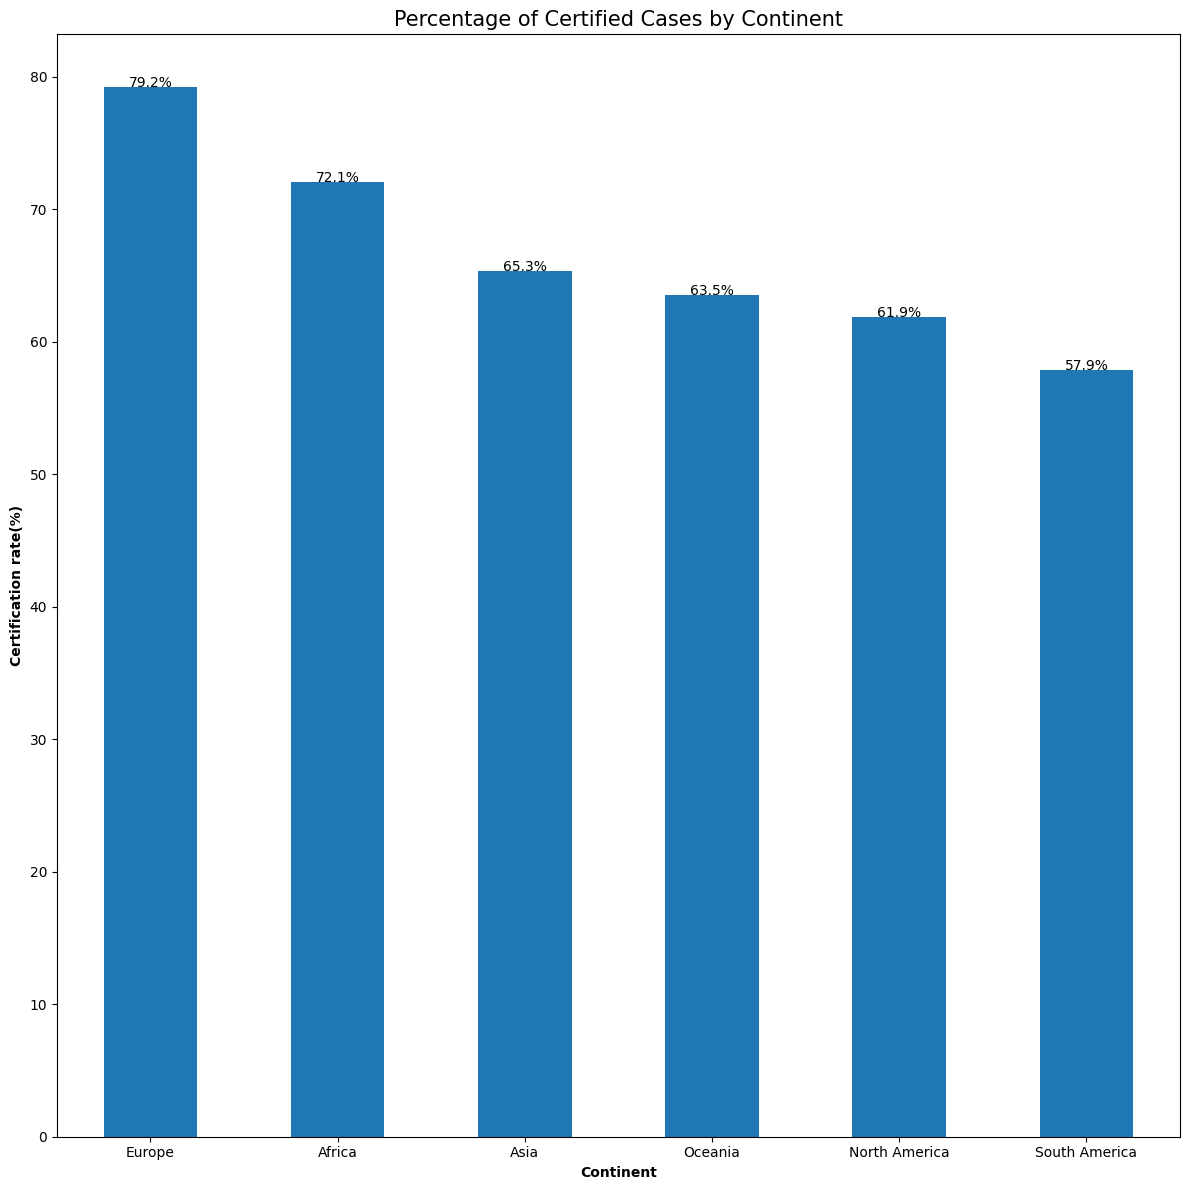

In [21]:
# Visualize the proportion of certified visa application in every continent

df2 = df.copy()

plt.figure(figsize=(12,12))

# calculate certified rate per continent

cert_rate = (
    df2[df2["case_status"] == "Certified"] # filter dataframe to keep only row where case-status = Certified
    .groupby("continent") # group the certified cases by continent
    .size() # count the number of certified case per continent group
    .div(df2.groupby("continent").size()) # divide by total count of continent give proportion of certified case per continent
    .mul(100) # convert it to percentage  
    .sort_values(ascending=False) 
)

fig, ax = plt.subplots(figsize=(12,12))
cert_rate.plot(kind="bar", ax=ax, linewidth=0.5) # cert_rate compute (index=continent,values=%), ax=ax =draw on explicit axis object
for i, value in enumerate(cert_rate):
    ax.text(i,value,f"{value:.1f}%",ha="center",fontsize=10)
    ax.set_title("Percentage of Certified Cases by Continent", fontsize=15)
    ax.set_xlabel("Continent",fontweight="bold")
    ax.set_ylabel("Certification rate(%)",fontweight="bold")
    ax.tick_params(axis="x",rotation=0) # keep contiennt name horizontal (rotation = 0)
plt.tight_layout()







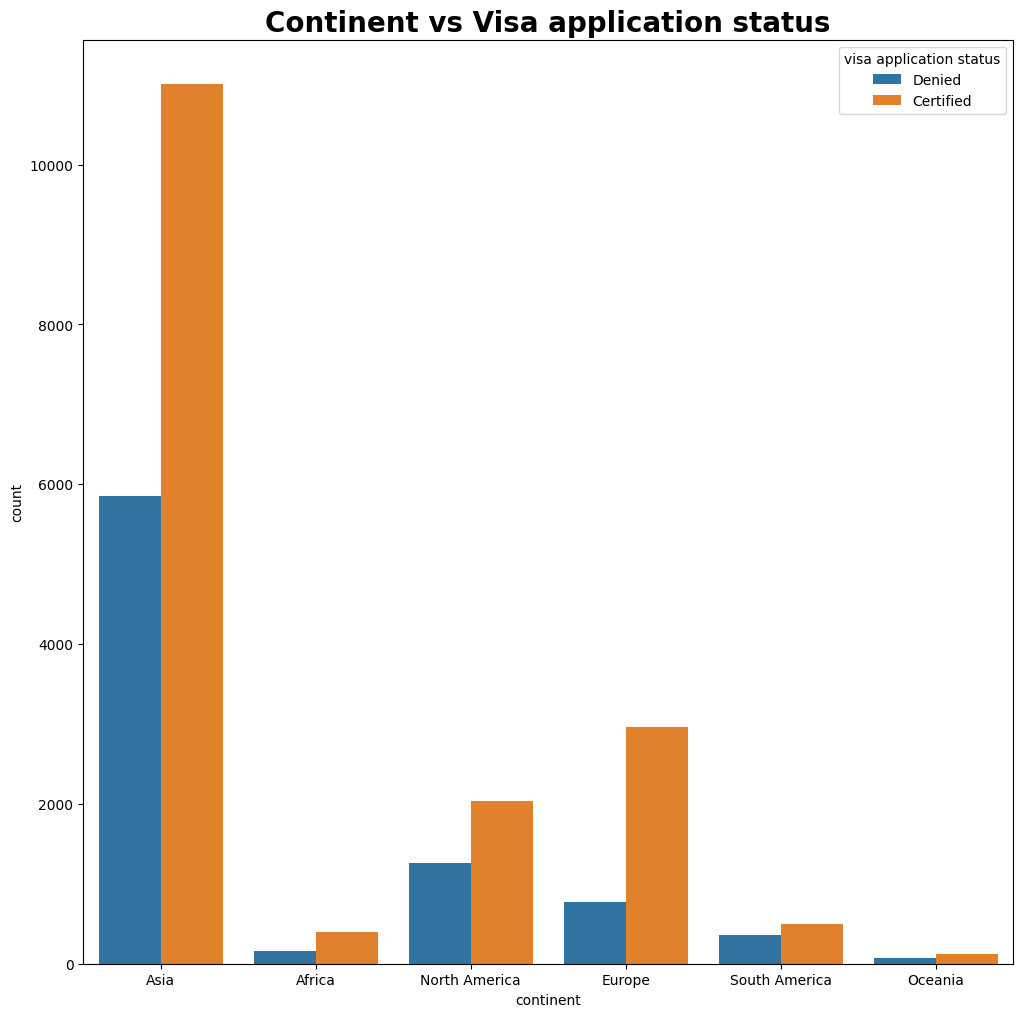

In [22]:
# Visualize the continent with the visa applcation status

plt.figure(figsize=(12,12))
sb.countplot(data=df, x="continent", hue="case_status")
plt.title("Continent vs Visa application status",fontsize=20,weight="bold")
plt.xlabel("continent")
plt.ylabel("count")
plt.legend(title="visa application status",fancybox=True)
plt.show()

In [23]:
cert_only = df[df["case_status"]=="Certified"]

continent_share = (
    cert_only["continent"].value_counts()    
    .div(len(cert_only))
    .mul(100)
    .round(1)
)

print(continent_share)

continent
Asia             64.7
Europe           17.4
North America    12.0
South America     2.9
Africa            2.3
Oceania           0.7
Name: count, dtype: float64


Interpretation 

1. Most of the visa applicant are from Asia and the least visa applicant are from Ocenia.

2. 64.7% of Certified application are from Asia follow by Europe with  17.4% of certified applications.

3. Highest chance of getting certified visa aaplication if you are from Rurope followed by Africa. 

In [24]:
# Multivariate analysis 
# Find out the impact of visa applicant education background to the application status 

df.groupby("education_of_employee")["case_status"].value_counts(normalize=True).to_frame()*100


proportion
education_of_employee case_status            
Bachelor's            Certified     62.214188
                      Denied        37.785812
Doctorate             Certified     87.226277
                      Denied        12.773723
High School           Denied        65.964912
                      Certified     34.035088
Master's              Certified     78.627777
                      Denied        21.372223

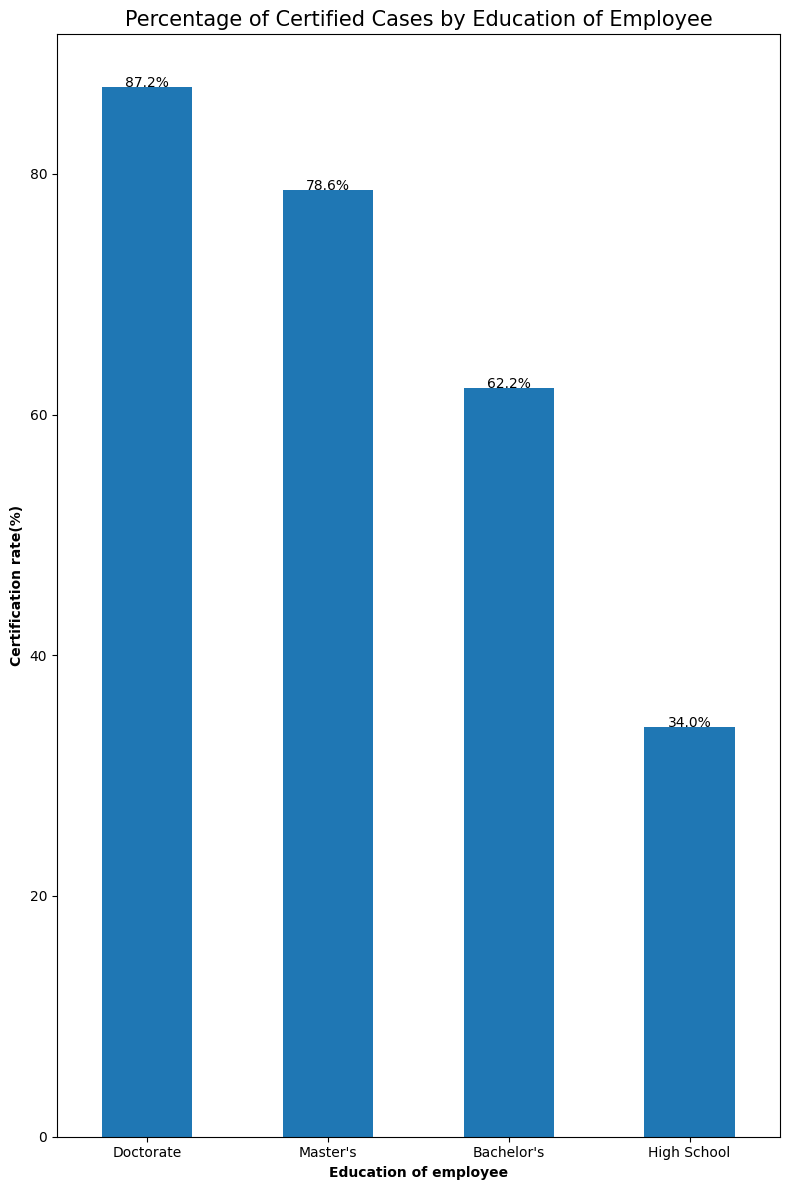

In [25]:
# visualize the certified rate per education level

cert_rate_edu = (
    df2[df2["case_status"] == "Certified"]
    .groupby("education_of_employee")
    .size()
    .div(df2.groupby("education_of_employee").size())
    .mul(100)
    .sort_values(ascending=False)
 )

fig, ax = plt.subplots(figsize=(8,12))
cert_rate_edu.plot(kind="bar",ax=ax,linewidth=0.5)
for i, value in enumerate(cert_rate_edu):
    ax.text(i,value,f"{value:.1f}%",ha="center",fontsize=10)
    ax.set_title("Percentage of Certified Cases by Education of Employee", fontsize=15)
    ax.set_xlabel("Education of employee",fontweight="bold")
    ax.set_ylabel("Certification rate(%)",fontweight="bold")
    ax.tick_params(axis="x",rotation=0) # keep x variable name horizontal (rotation = 0)
plt.tight_layout()

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

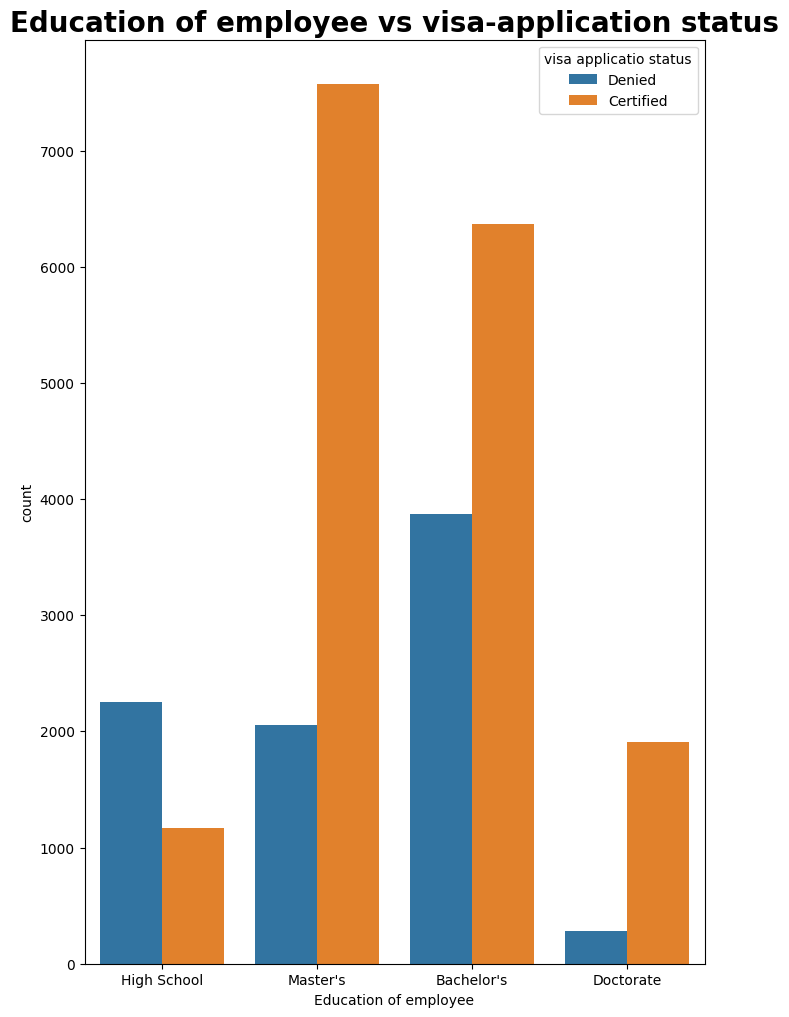

In [26]:
# Visualize  the education level of applicant with case status
 
plt.figure(figsize=(8,12))
sb.countplot(data=df,x="education_of_employee",hue="case_status")
plt.title("Education of employee vs visa-application status", fontsize=20, fontweight="bold")
plt.xlabel("Education of employee")
plt.ylabel("count")
plt.legend(title="visa applicatio status",fancybox=True)
plt.tight_layout


In [27]:
# To find out the overall certified rate base on education
cert_only = df[df["case_status"]=="Certified"]

education_share = (
    cert_only["education_of_employee"].value_counts()    
    .div(len(cert_only))
    .mul(100)
    .round(1)
)

print(education_share)

education_of_employee
Master's       44.5
Bachelor's     37.4
Doctorate      11.2
High School     6.8
Name: count, dtype: float64


Interpretation

1. applicants with Doctorate education level have highest certified rate followed by master's education level.

2. Most of the applicant for the US Visa are from Master's education level followed by Bachelor's educaltion level.

3. Education background does matter to the US visa application 


In [28]:
# Multivariate analysis
# Find out the impact of work experience on visa application status

df.groupby("has_job_experience")["case_status"].value_counts(normalize=True).to_frame()*100



proportion
has_job_experience case_status            
N                  Certified     56.134108
                   Denied        43.865892
Y                  Certified     74.476422
                   Denied        25.523578

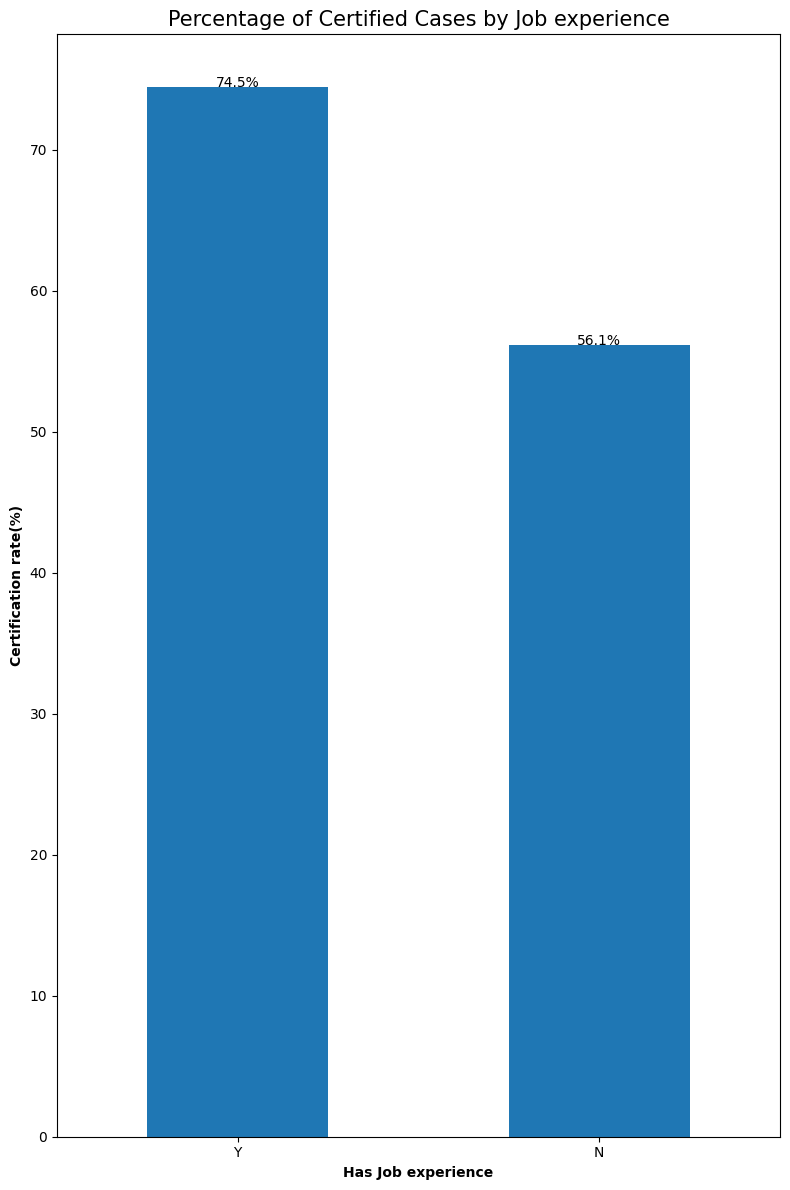

In [29]:
# Visualise the proportion of certified rate on the work experience 

cert_rate_work_exp = (
    df2[df2["case_status"] == "Certified"]
    .groupby("has_job_experience")
    .size()
    .div(df2.groupby("has_job_experience").size())
    .mul(100)
    .sort_values(ascending=False)
 )

fig, ax = plt.subplots(figsize=(8,12))
cert_rate_work_exp.plot(kind="bar",ax=ax,linewidth=0.5)
for i, value in enumerate(cert_rate_work_exp):
    ax.text(i,value,f"{value:.1f}%",ha="center",fontsize=10)
    ax.set_title("Percentage of Certified Cases by Job experience", fontsize=15)
    ax.set_xlabel("Has Job experience",fontweight="bold")
    ax.set_ylabel("Certification rate(%)",fontweight="bold")
    ax.tick_params(axis="x",rotation=0) # keep x variable name horizontal (rotation = 0)
plt.tight_layout()

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

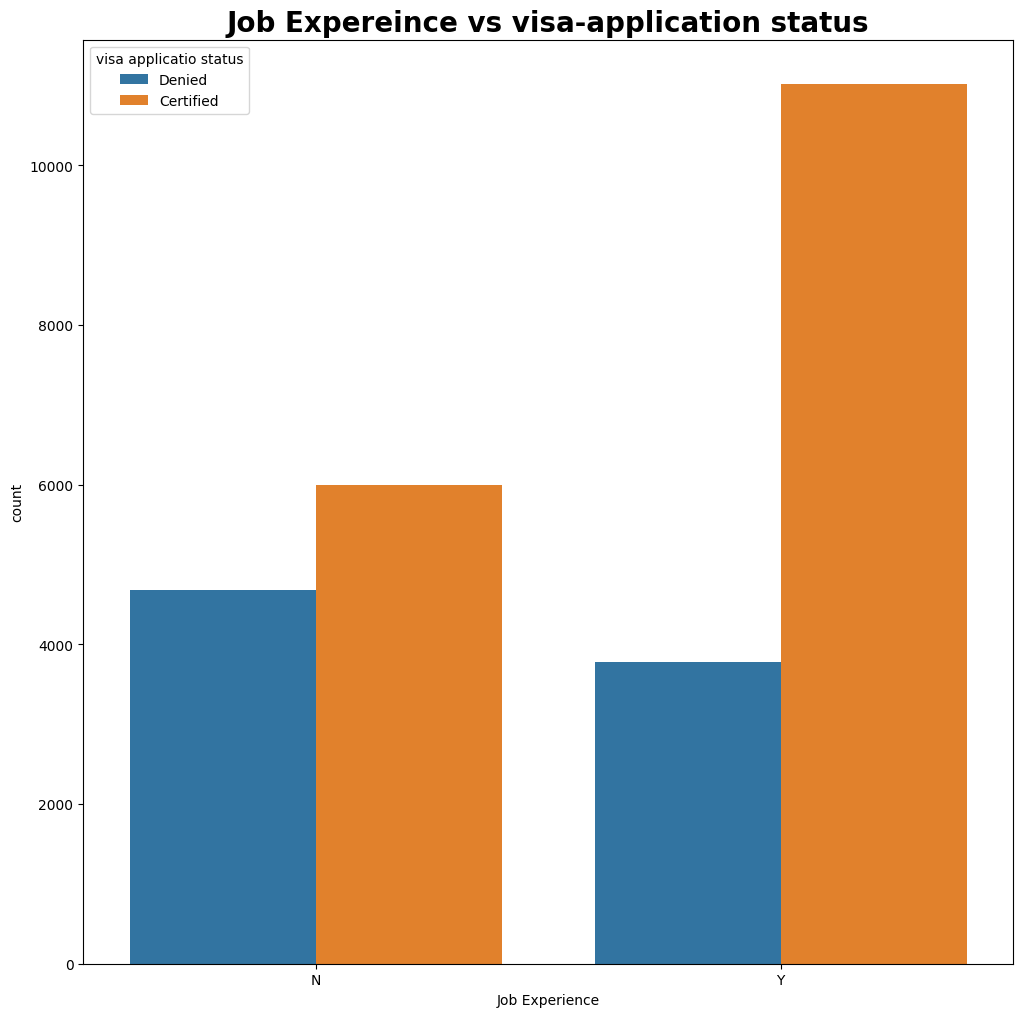

In [30]:
# Visualize  the education level of applicant with case status
 
plt.figure(figsize=(12,12))
sb.countplot(data=df,x="has_job_experience",hue="case_status")
plt.title("Job Expereince vs visa-application status", fontsize=20, fontweight="bold")
plt.xlabel("Job Experience")
plt.ylabel("count")
plt.legend(title="visa applicatio status",fancybox=True)
plt.tight_layout

In [31]:
# To find out the overall certified rate base on job Experience
job_exp_share = (
    cert_only["has_job_experience"].value_counts()    
    .div(len(cert_only))
    .mul(100)
    .round(1)
)

print(job_exp_share)

has_job_experience
Y    64.8
N    35.2
Name: count, dtype: float64


Interpretation

1. People with previous work experience has been certified 74.5% only 25.5% applicant has been denied.

2. People with No previous work experience has been certified 56% and denied 43%.

3. This means work experience has effect on Visa status.

4. Overall 64.8% of certified visa application are come from people who have previous job expereince 

In [32]:
# Multivariete Analysis 
# Find out the impact of job training on visa application 

df.groupby("requires_job_training")["case_status"].value_counts(normalize=True).to_frame()*100

proportion
requires_job_training case_status            
N                     Certified     66.645949
                      Denied        33.354051
Y                     Certified     67.884941
                      Denied        32.115059

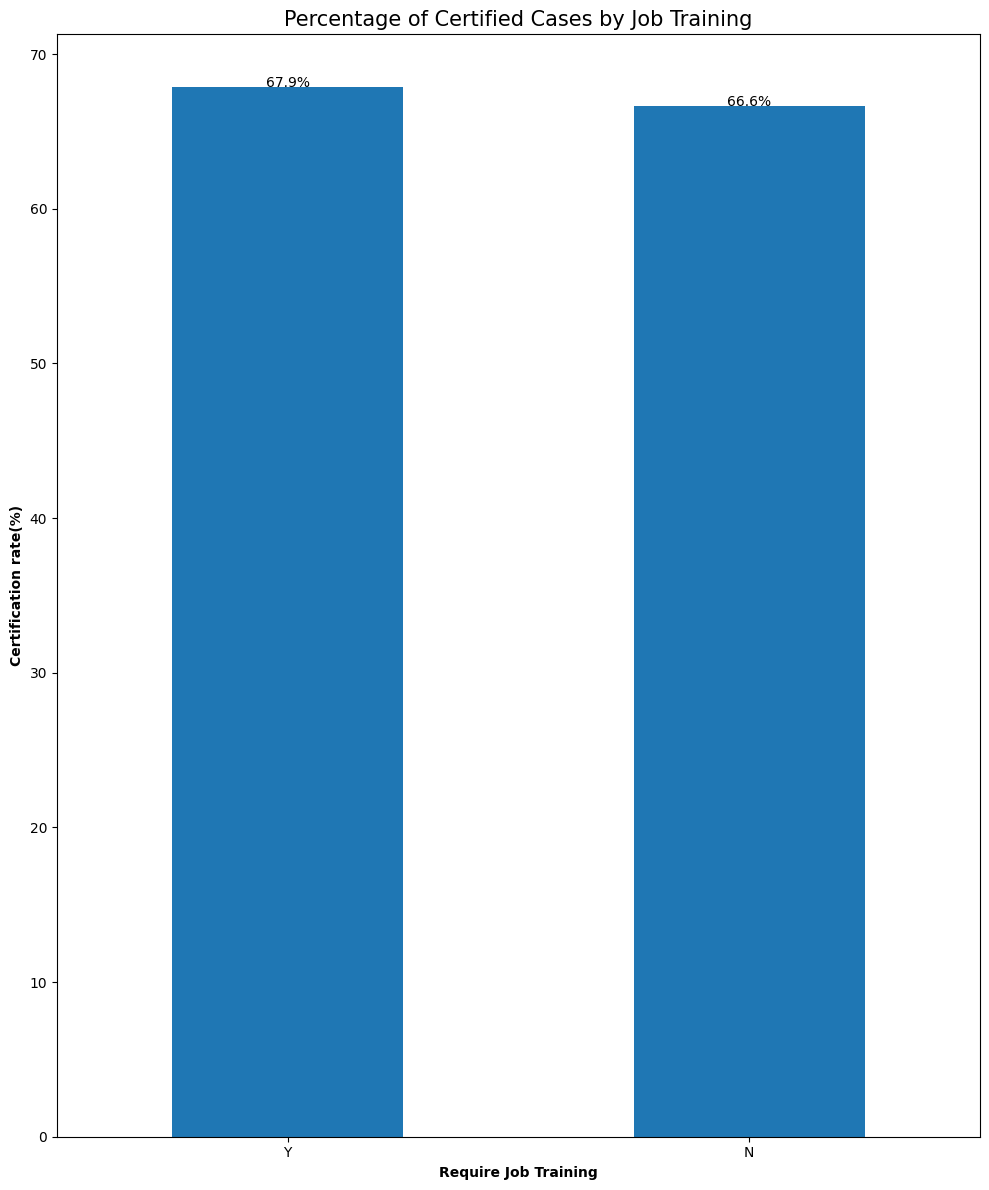

In [33]:
# Visualize the certified of job training 

cert_rate_job_train = (
    df2[df2["case_status"]=="Certified"]
    .groupby("requires_job_training")
    .size()
    .div(df2.groupby("requires_job_training").size())
    .mul(100)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10,12))
cert_rate_job_train.plot(kind="bar",ax=ax)
for i, value in enumerate(cert_rate_job_train):
    ax.text(i,value,f"{value:.1f}%",ha="center",fontsize=10)
    ax.set_title("Percentage of Certified Cases by Job Training", fontsize=15)
    ax.set_xlabel("Require Job Training",fontweight="bold")
    ax.set_ylabel("Certification rate(%)",fontweight="bold")
    ax.tick_params(axis="x",rotation=0) # keep x variable name horizontal (rotation = 0)
plt.tight_layout()


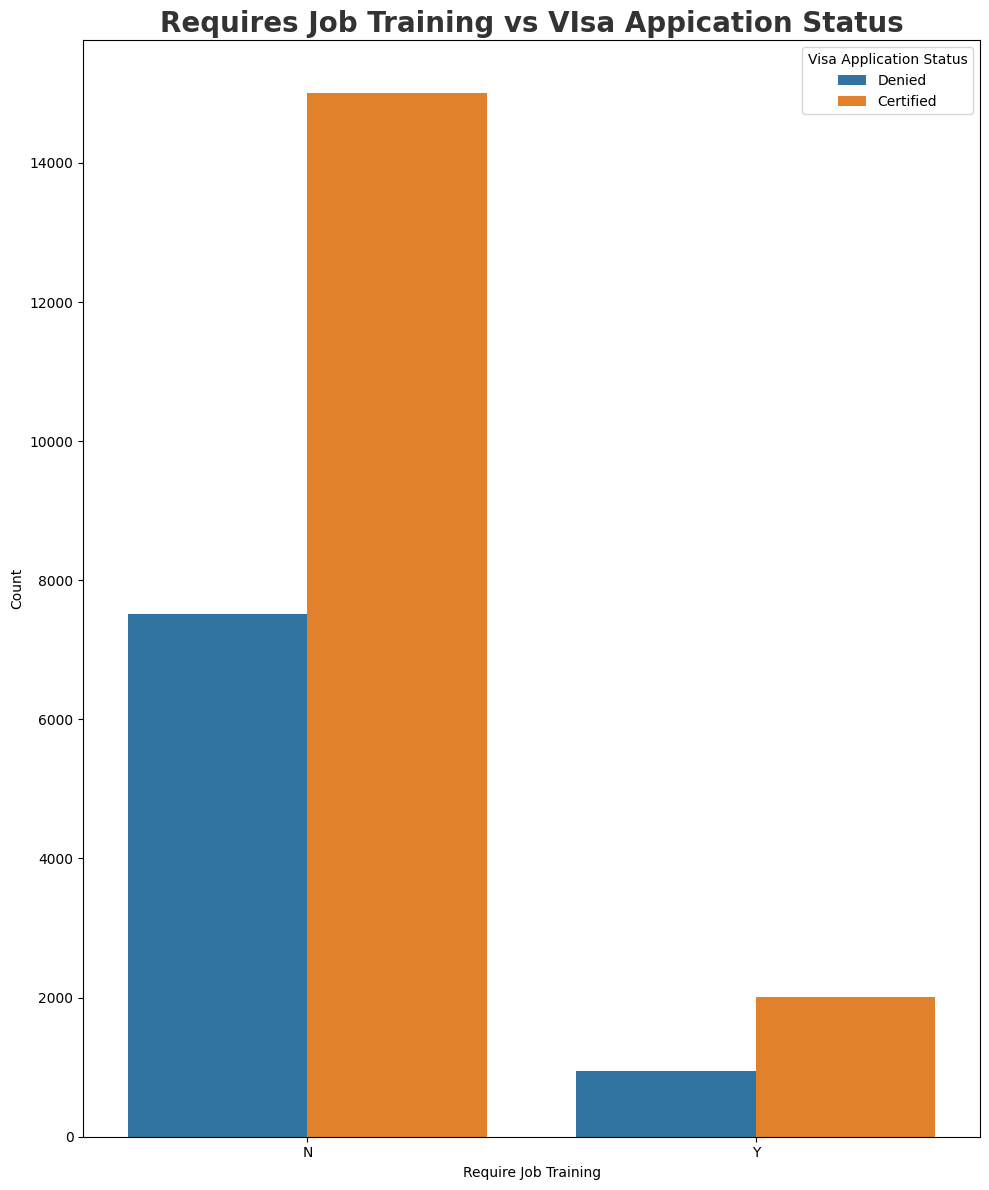

In [34]:
# Visualise the count value of require job training vs visa application status

plt.figure(figsize=(10,12))
sb.countplot(data=df,x="requires_job_training",hue=("case_status"))
plt.title("Requires Job Training vs VIsa Appication Status", fontsize=20,fontweight="bold",alpha=0.8)
plt.xlabel("Require Job Training")
plt.ylabel("Count")
plt.legend(title="Visa Application Status")
plt.tight_layout()

In [35]:
# To find out the overall certified rate base job training

job_train_share = (
    cert_only["requires_job_training"].value_counts()    
    .div(len(cert_only))
    .mul(100)
    .round(1)
)

print(job_train_share)

requires_job_training
N    88.2
Y    11.8
Name: count, dtype: float64


Interpretation 

1. The successful rate of certified visa application is almost the same in both with job training (67.9%) and without job training (66.6%).

2. 88% of certified applicant are without job training

3. This indicate that requires_job_training feature are not much impacting the visa application status as we checked Chi-Squared test this feature doesn't have much impact on target variable

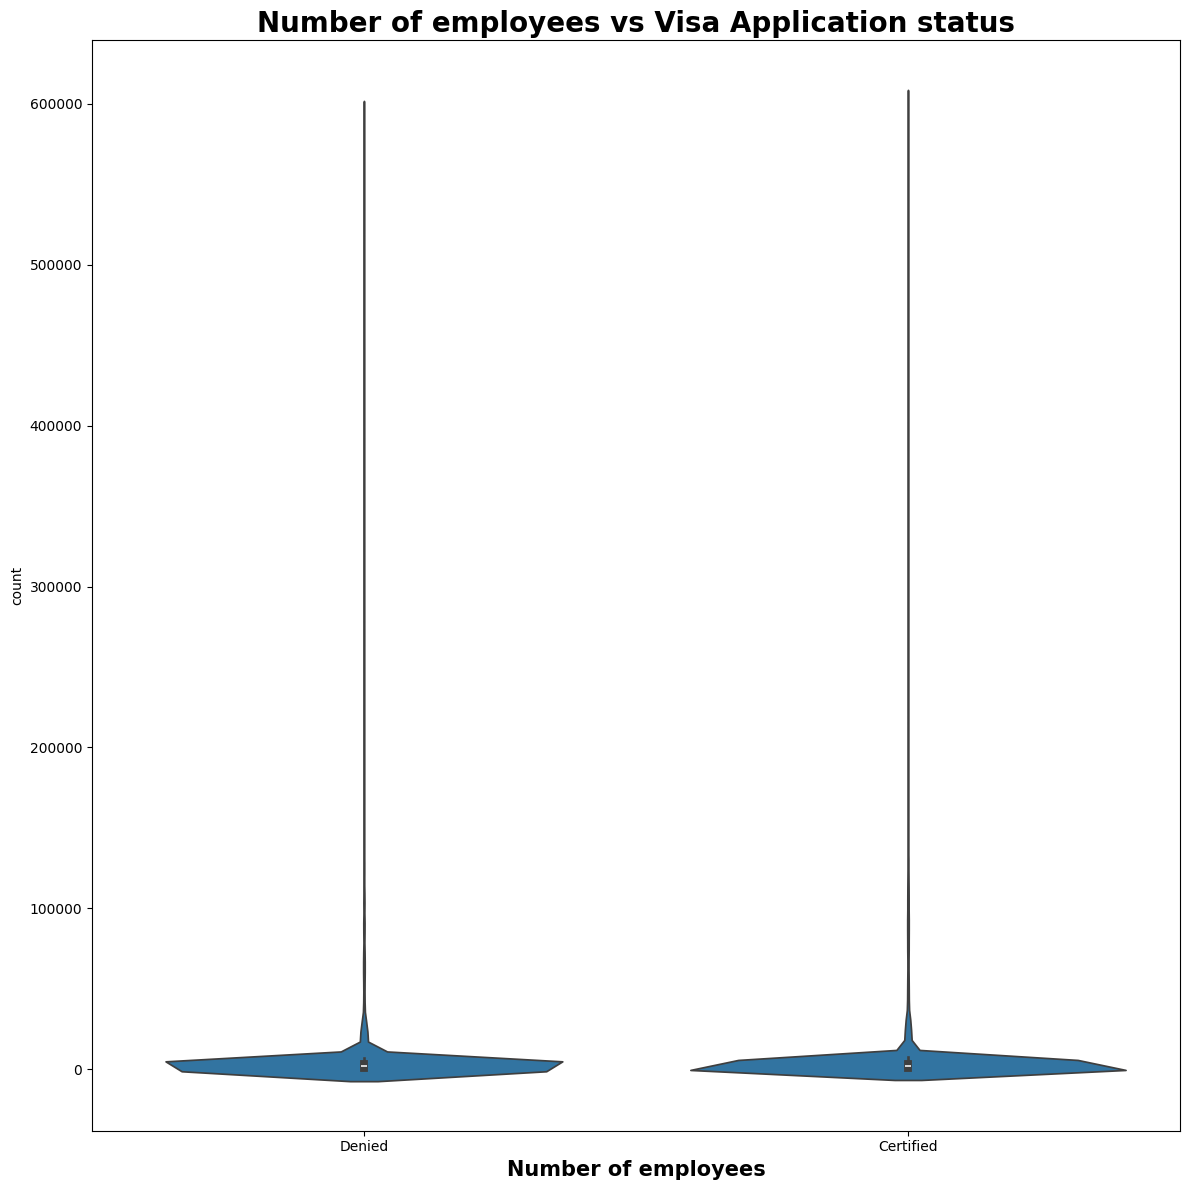

In [ ]:
# Multivariate analysis 
# Find out the impact of no of employee on visa application status 
# by visualise it with violin graph 
# Do not do groupby for continuos value as it is with a huge number of unique values
# we use violiin plot to find out the distribution

plt.figure(figsize=(12,12))
sb.violinplot(data=df,x="case_status", y="no_of_employees")
plt.title("Number of employees vs Visa Application status", fontsize= 20, fontweight="bold")
plt.xlabel("Number of employees",fontweight="bold",fontsize=15)
plt.ylabel("count")
plt.tight_layout()



Interpretation 

1. The distribution of both is similar, outlier in both classes should be handle before modelling

In [37]:
# Mulyivariate analysis 
# Find out impact of region of establishment on visa application status

df.groupby("region_of_employment")["case_status"].value_counts(normalize=True).to_frame()*100

proportion
region_of_employment case_status            
Island               Certified     60.266667
                     Denied        39.733333
Midwest              Certified     75.528210
                     Denied        24.471790
Northeast            Certified     62.904795
                     Denied        37.095205
South                Certified     70.015676
                     Denied        29.984324
West                 Certified     62.253265
                     Denied        37.746735

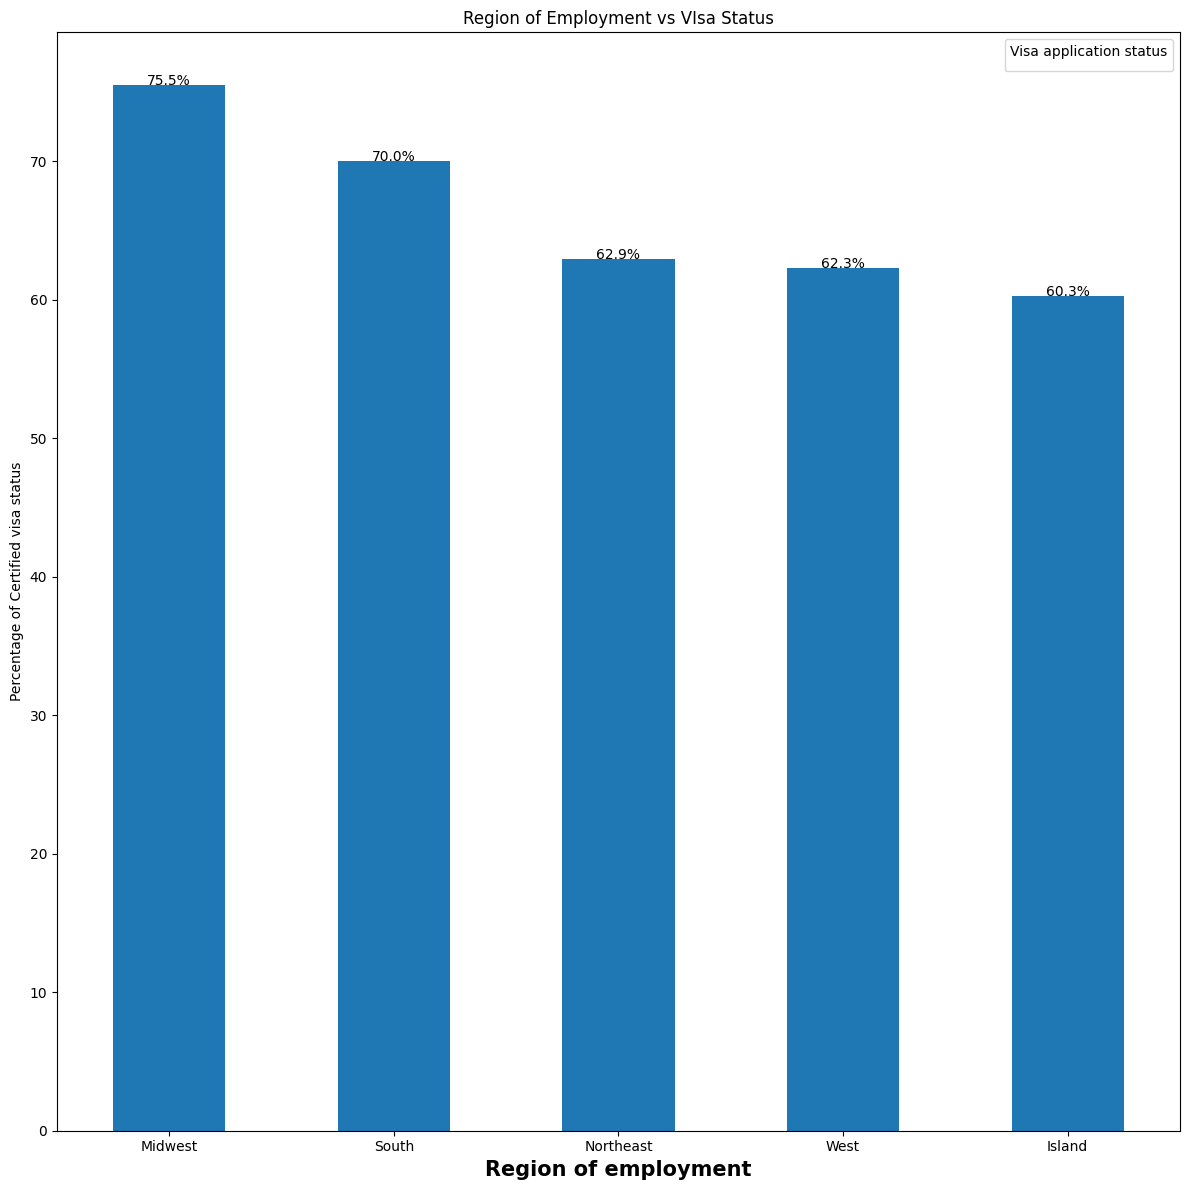

In [38]:
# Visualise the percentage of certified rate within region

cert_rate_region = (
    df2[df2["case_status"]=="Certified"]
    .groupby("region_of_employment")
    .size()
    .div(df2.groupby("region_of_employment").size())
    .mul(100)
    .sort_values(ascending=False)
)

fig , ax = plt.subplots(figsize=(12,12))
cert_rate_region.plot(kind="bar",ax=ax)
for i, value in enumerate(cert_rate_region):
    ax.text(i,value,f"{value:.1f}%",ha="center",fontsize=10)
    ax.set_xlabel("Region of employment",fontsize=15,fontweight="bold")
    ax.set_ylabel("Percentage of Certified visa status")
    ax.set_title("Region of Employment vs VIsa Status")
    ax.legend(title="Visa application status")
    ax.tick_params(axis='x',rotation=0 )
plt.tight_layout()

In [39]:
# To find out the overall certified rate base on region
region_share = (
    cert_only["region_of_employment"].value_counts()    
    .div(len(cert_only))
    .mul(100)
    .round(1)
)

print(region_share)

region_of_employment
South        28.9
Northeast    26.6
West         24.1
Midwest      19.1
Island        1.3
Name: count, dtype: float64


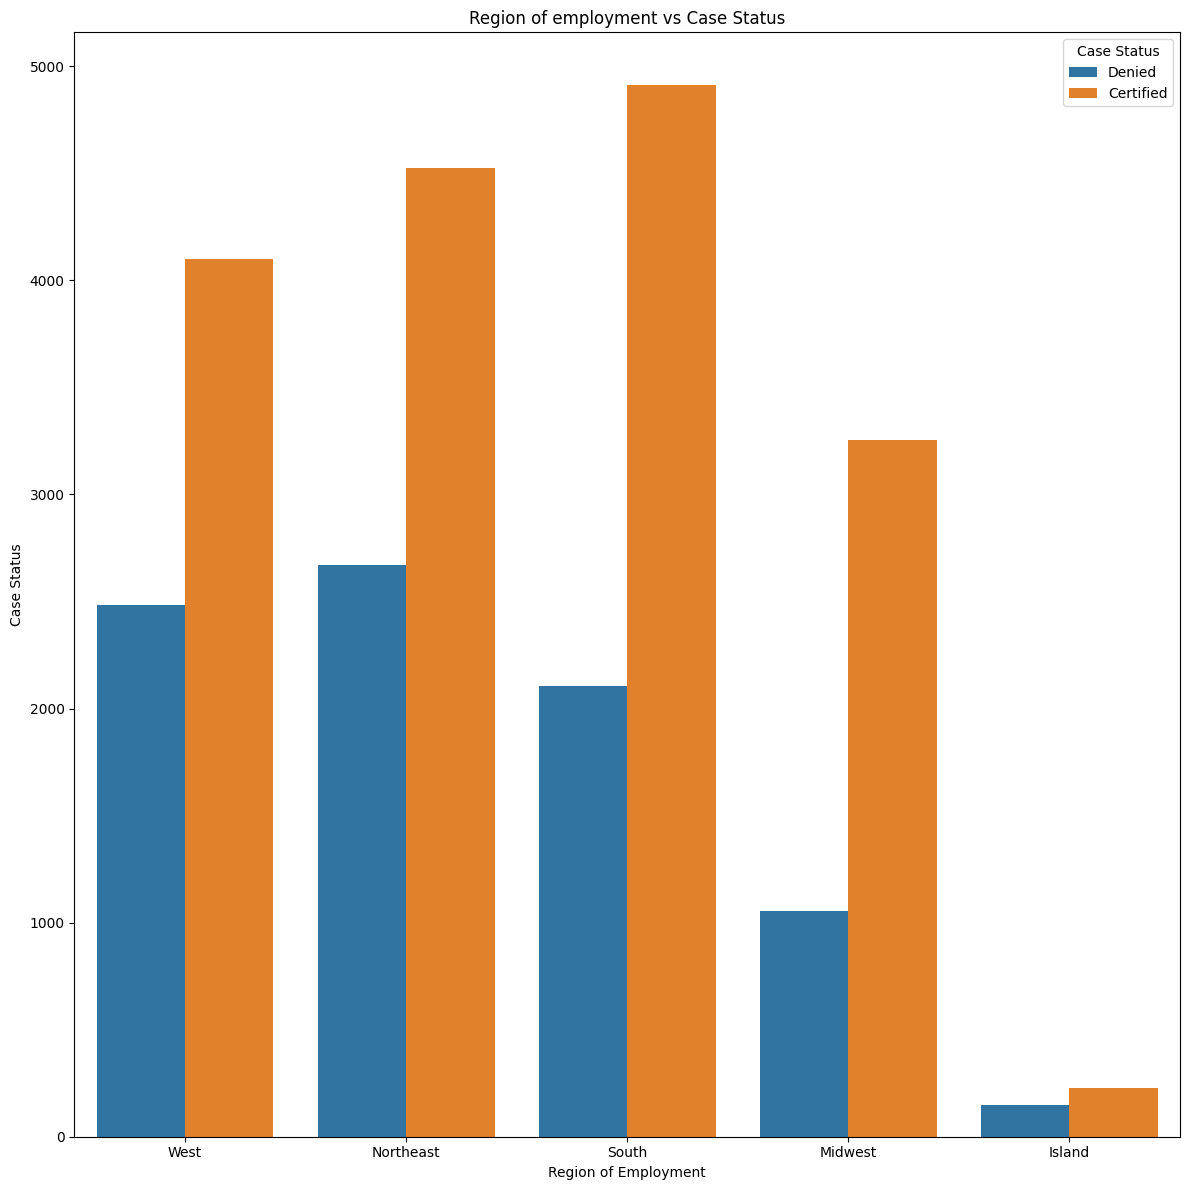

In [40]:
# Visualise all the application status base on region of employee

plt.figure(figsize=(12,12))
sb.countplot(data=df,x="region_of_employment",hue="case_status")
plt.xlabel("Region of Employment")
plt.ylabel("Case Status") 
plt.legend(title="Case Status")
plt.title("Region of employment vs Case Status")
plt.tight_layout()

Interpretation 

1. Midwest region has the highest certified rate (75.5%) and followed by SOuth region (70%)

2. Island has the overall lowest succesful certified visa rate of 1.3% than others region as it has the significant lower number of applicant than other region. 

In [41]:
# Multivariate analysis to find out the impact of unit of wages on visa application status

df.groupby("unit_of_wage")["case_status"].value_counts(normalize=True).to_frame()*100

proportion
unit_of_wage case_status            
Hour         Denied        65.368567
             Certified     34.631433
Month        Certified     61.797753
             Denied        38.202247
Week         Certified     62.132353
             Denied        37.867647
Year         Certified     69.885027
             Denied        30.114973

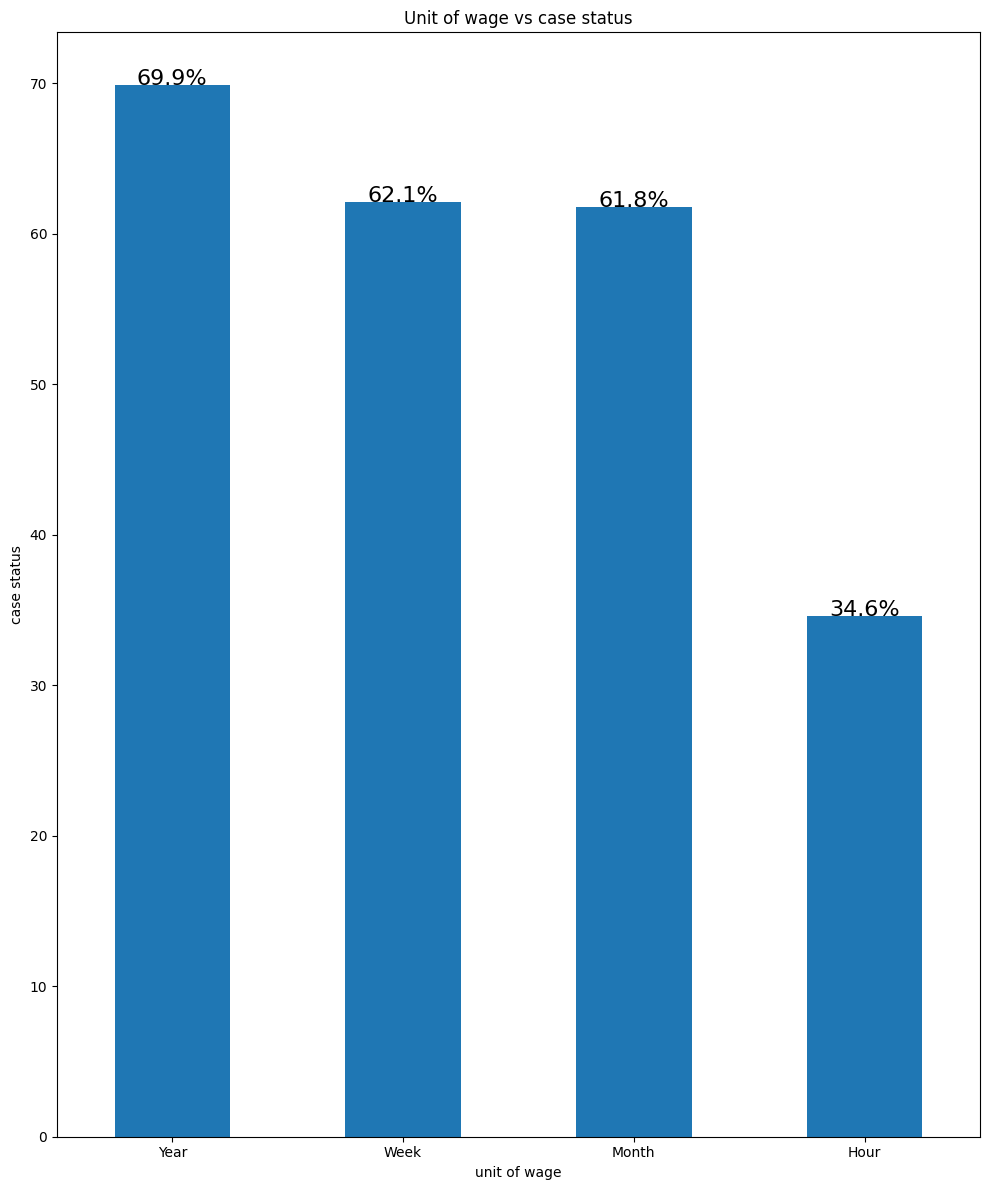

In [42]:
cert_wage = (
    df2[df2["case_status"]=="Certified"]
    .groupby("unit_of_wage")
    .size()
    .div(df.groupby("unit_of_wage").size())
    .mul(100)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10,12))
cert_wage.plot(kind="bar",ax=ax)
for i, value in enumerate(cert_wage):
    ax.text(i,value,f"{value:.1f}%",ha="center",fontsize=16)
    ax.set_title("Unit of wage vs case status")
    ax.set_xlabel("unit of wage")
    ax.set_ylabel("case status")
    ax.tick_params(rotation=0,axis="x")
plt.tight_layout()

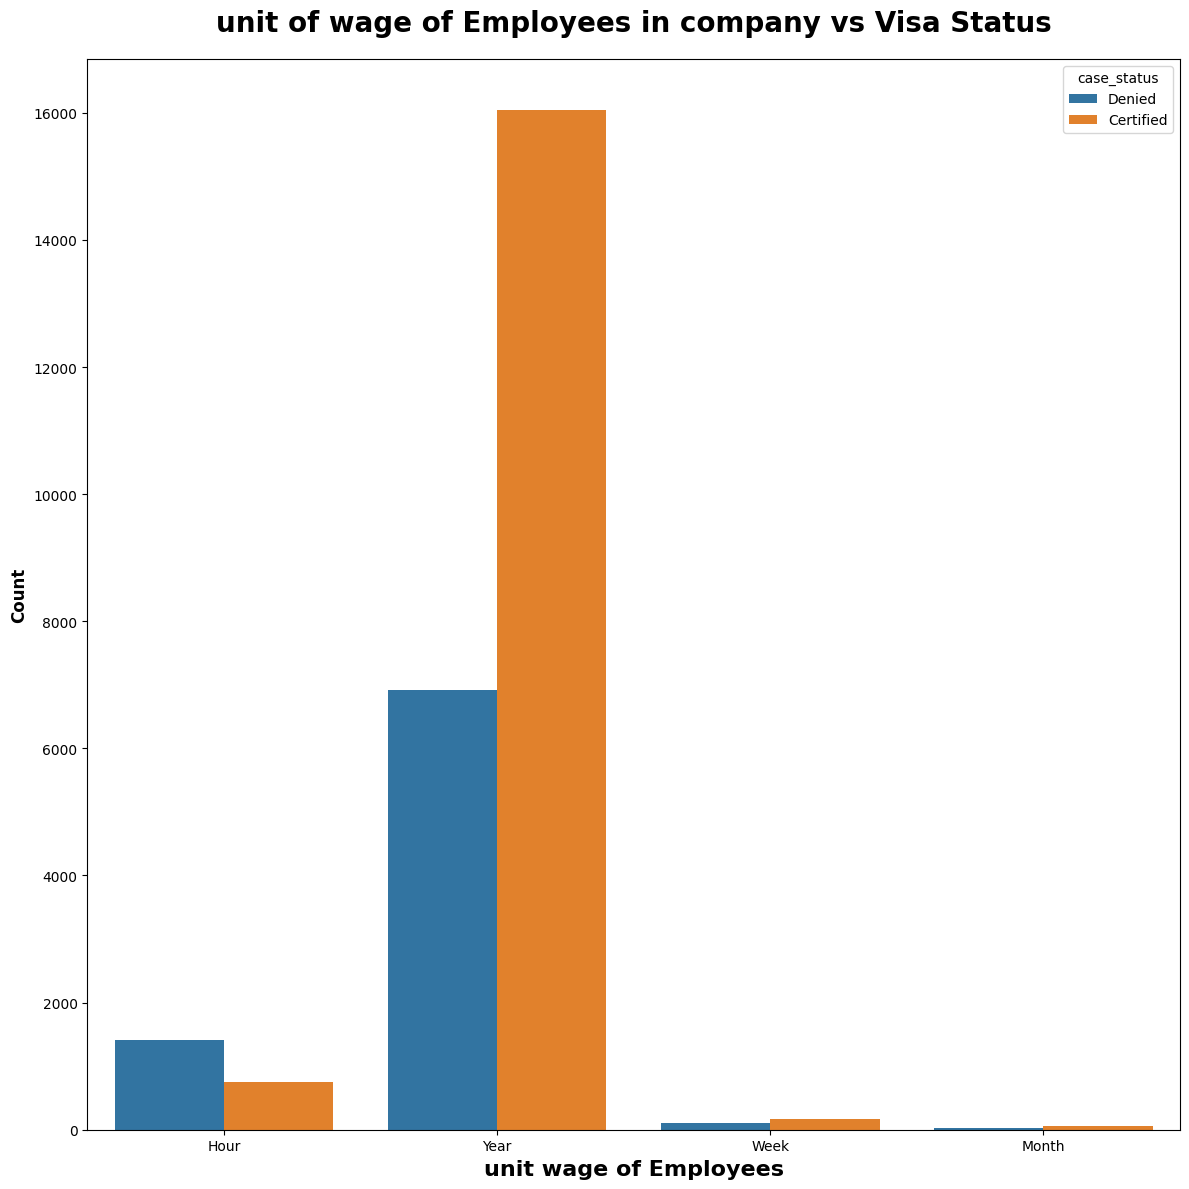

In [43]:
# Visualise the total unit of wage with case status

plt.figure(figsize=(12,12))
sb.countplot(x="unit_of_wage",hue="case_status",data=df)
plt.title("unit of wage of Employees in company vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("unit wage of Employees", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.tight_layout()

In [44]:
unit_wage_share=(
    cert_only["unit_of_wage"].value_counts()
    .div(len(cert_only))
    .mul(100)
    .round(1)
)

print(unit_wage_share)

unit_of_wage
Year     94.3
Hour      4.4
Week      1.0
Month     0.3
Name: count, dtype: float64


Interpretation 

1. Year base wage are dominate the certified US visa status with 94.3% 

2. Hour base wage are the lowest certified rate at 34.6% and all others base wage are having alomst the same succesfull certified rate.  

In [ ]:
# Multivaraite analysis 
# Find out impact of prevailing wage on visa application status
# Visualise with histogram

# first we find out the direct impact of prevailing wage on the visa application status
df.groupby("case_status")["prevailing_wage"].agg(["mean","median","std"]) # groupby categorical and aggregate the numeric wage

,mean,median,std
case_status,,,
Certified,77293.619243,72486.27,52042.715576
Denied,68748.681580,65431.46,53890.166031


Interpretation 

1. From above we can see that higher prevailing wages will increase the successful rate of certified visa application

2. We have to find out what drive prevailing wage as it explain the differences of wages that will impact the visa application rate 


In [63]:
# To find out the wage differences we compare with education, job experience, and continent

# First we find out the multivaraite analysis on wage and education

df.groupby(["education_of_employee","unit_of_wage"])["prevailing_wage"].median().to_frame().sort_values(by="unit_of_wage",ascending=False)

,,prevailing_wage
education_of_employee,unit_of_wage,
Bachelor's,Year,76547.44500
Doctorate,Year,60283.18000
High School,Year,74347.50500
Master's,Year,79715.64000
Bachelor's,Week,85847.91500
Doctorate,Week,71687.76500
High School,Week,82007.77500
Master's,Week,86385.69000
Bachelor's,Month,81826.01000


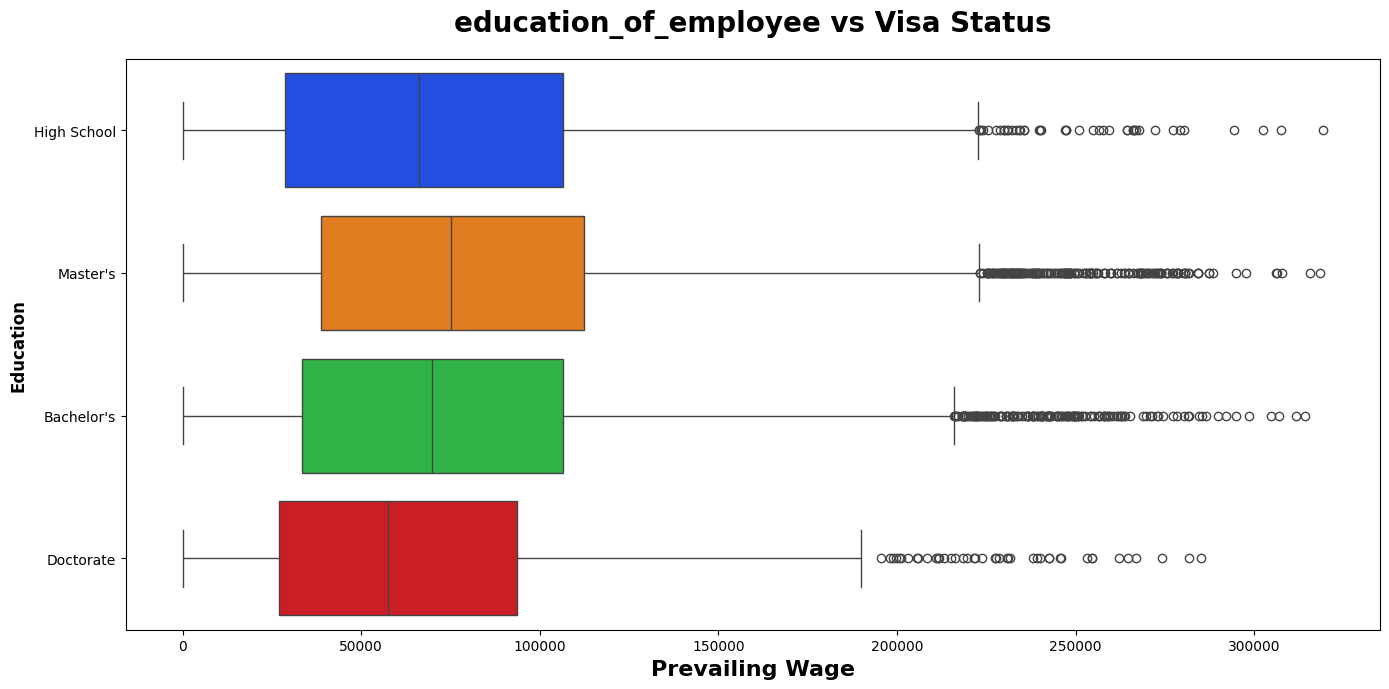

In [57]:
plt.subplots(figsize=(14,7))
# boxplot is used when there are continuos number 
sb.boxplot(y="education_of_employee",x = "prevailing_wage", data=df,palette='bright')  
plt.title("education_of_employee vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("Prevailing Wage", weight="bold", fontsize=16)
plt.ylabel("Education", weight="bold", fontsize=12)
plt.tight_layout()

Interpretation

1. Base on the boxplot above, we can see that applicant with Master' education has highest average prevailing wages

2. Master"education level median prevailing wage is 78.8k 

3. Even though Doctorate is the highest education level but the median prevailing wage is the lowest with 57.5k.

4. Assuption of higher education level with higher prevailing wage is not applicable

In [ ]:
# Second we find out the multivariate analysis on prevailing wage with job experience
print('Median Prevailing wage based on Job experience')
df.groupby('has_job_experience')['prevailing_wage'].median().to_frame().sort_values(by='prevailing_wage',ascending=False)

Median Prevailing wage based on Job experience


,prevailing_wage
has_job_experience,
N,72602.290
Y,69033.665


Interpretation 

1. No job experience applicant has higher prevailing wage at 72.6k than applicant with job experience at 69k.

 

In [64]:
# Find out the multivaraite analysis of continent with prevailing wage

df.groupby("continent")["prevailing_wage"].median().to_frame().sort_values(by="prevailing_wage", ascending=False)

,prevailing_wage
continent,
Asia,76168.880
Africa,75126.310
Oceania,68656.045
North America,64289.875
South America,53511.705
Europe,52073.335


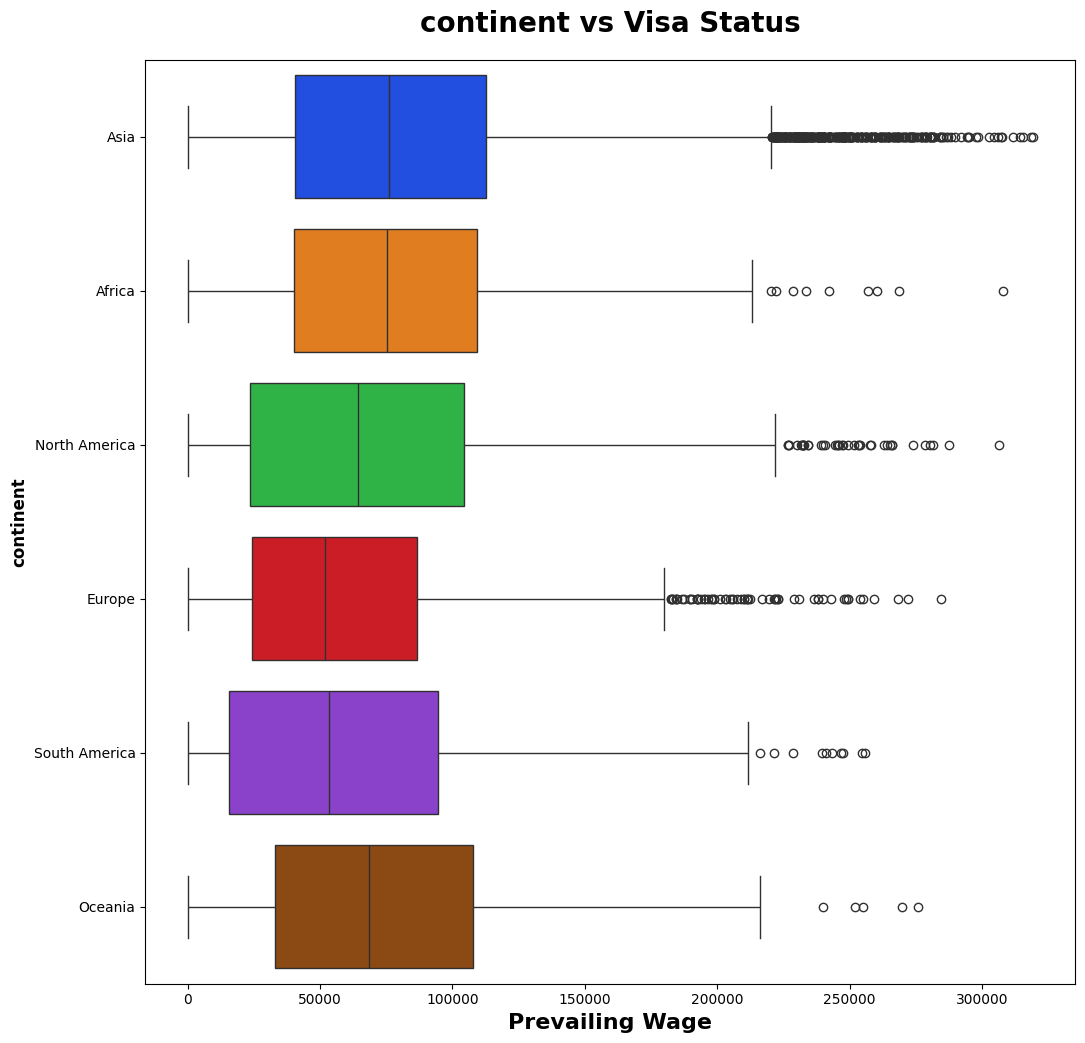

In [66]:
plt.figure(figsize=(12,12))
sb.boxplot(data=df,x="prevailing_wage",y="continent",palette="bright")
plt.title("continent vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("Prevailing Wage", weight="bold", fontsize=16)
plt.ylabel("continent", weight="bold", fontsize=12)
plt.show()

Interpretation 

1. Asia has the highest prevailing wage and followed by Africa

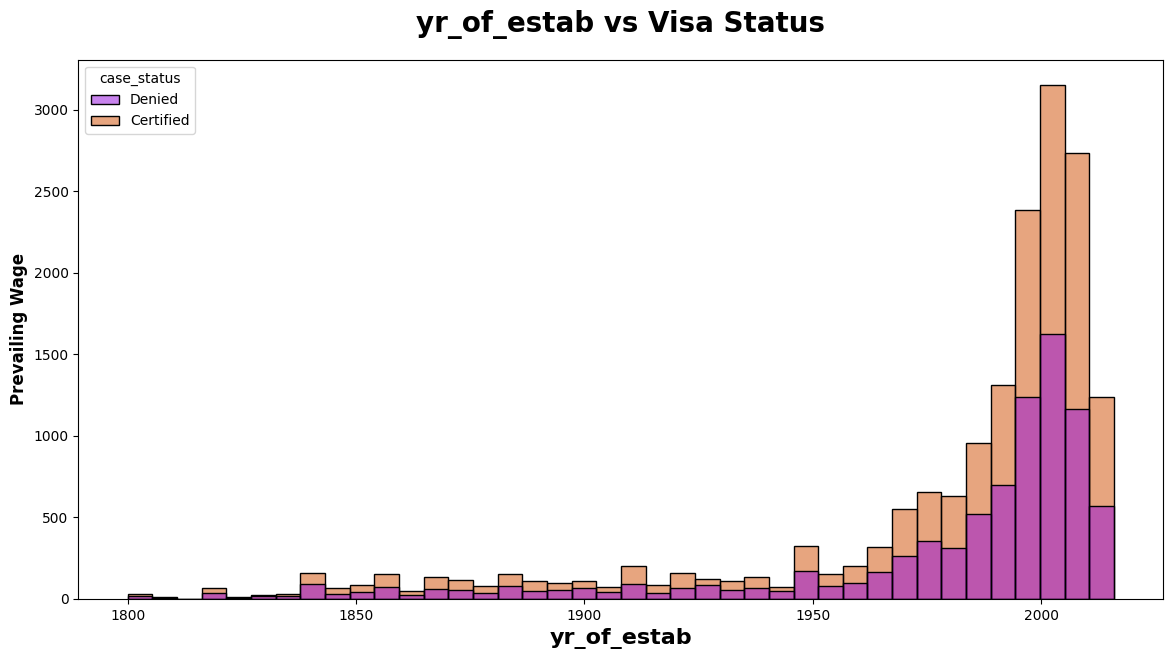

In [67]:

plt.subplots(figsize=(14,7))
sb.histplot(x = "yr_of_estab", data=df,palette='gnuplot', bins=40, hue='case_status')
plt.title("yr_of_estab vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("yr_of_estab", weight="bold", fontsize=16)
plt.ylabel("Prevailing Wage", weight="bold", fontsize=12)
plt.show()

Interpretation 

1. Each bins consists of 5 years.
2. Many companies were established after year 2000.
3. The most company establishment happened in year 2000-2005

Final Report / Conclusion

1. Data type - 9 String, 2 integer, and 1 float.
2. 25479 rows, 12 columns 
3. Null number and Duplicates are not existed in this dataset. 
4. case_ID and requires_job_traning features can be dropped as   it does not have much impact toward target variable.
5. no_of_employees, prevailing_wage and yr_of_estab has outlier, should be handle before modelling
6. Target variable - case_status is imbalance should be handle before modelling

